## Multiple holdings portfolio return calculator

Handles a client with multiple holdings across Equities, Bonds, and REITs.
For each holding, the client is only asked simple, non-technical questions (ticker or bond details, units purchased, purchase date). The tool then: 
1. Calculates the return on each individual holding (price gain + income earned)
2. Prints a summary TABLE across the whole portfolio
3. Draws a pie chart showing current allocation across holdings
4. Optionally saves everything to CSV and a PNG chart

In [1]:
import sys
from datetime import datetime, date
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
def ask(prompt, cast=str, default=None):
    while True:
        raw = input(prompt).strip()
        if not raw and default is not None:
            return default
        try:
            return cast(raw)
        except ValueError:
            print("  Sorry, I didn't get that — please try again.")

def ask_date(prompt):
    while True:
        raw = input(prompt).strip()
        for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y"):
            try:
                return datetime.strptime(raw, fmt).date()
            except ValueError:
                continue
        print("  Please enter the date like 2023-01-15 (YYYY-MM-DD).")

def money(x):
    return f"${x:,.2f}"

In [3]:
def calculate_equity_or_reit(group):
    ticker_symbol = ask(f"  Ticker symbol (Use companies listed on NYSE e.g. AAPL, VNQ): ").upper() 
    shares = ask("  Number of shares/units purchased: ", float)
    purchase_date = ask_date("  Purchase date (YYYY-MM-DD): ")

    print(f"  Looking up {ticker_symbol}...")
    tkr = yf.Ticker(ticker_symbol)
    hist = tkr.history(start=purchase_date.isoformat(), auto_adjust=False)
    if hist.empty:
        print(f"  Couldn't find price history for {ticker_symbol}. Skipping this holding.")
        return None

    purchase_price = float(hist["Close"].iloc[0])
    current_price = float(hist["Close"].iloc[-1])

    dividends = tkr.dividends
    if dividends is not None and not dividends.empty:
        dividends_since = dividends[dividends.index.date >= purchase_date]
        dividend_per_share = float(dividends_since.sum())
    else:
        dividend_per_share = 0.0

    initial_value = purchase_price * shares
    current_market_value = current_price * shares
    income_earned = dividend_per_share * shares
    price_gain = current_market_value - initial_value
    total_return_amount = price_gain + income_earned
    total_return_pct = (total_return_amount / initial_value) * 100 if initial_value else 0

    years_held = max((date.today() - purchase_date).days / 365.25, 1e-6)
    implied_annual_growth = (current_market_value / initial_value) ** (1 / years_held) - 1 if initial_value else 0

    return { "Investment": ticker_symbol, "Type": group, "Units": shares, "Purchase Date": purchase_date, "Initial Value": initial_value,
        "Current Value": current_market_value, "Income Earned": income_earned, "Price Gain/(Loss)": price_gain,  
        "Total Return ($)": total_return_amount, "Total Return (%)": total_return_pct, "_implied_growth": implied_annual_growth, }

In [4]:
def calculate_bond():
    face_value = ask("  Face value of ONE bond (e.g. 1000): ", float)
    num_bonds = ask("  Number of bonds purchased: ", float)
    coupon_rate_pct = ask("  Annual coupon rate, as a percent (e.g. 8): ", float)
    purchase_price_pct = ask( "  Price paid per bond, as % of face value (100 = par): ", float, default=100.0 )
    purchase_date = ask_date("  Purchase date (YYYY-MM-DD): ")
    current_price_pct = ask( "Current market price, as % of face value (same as purchase if unsure/holding to maturity): ", float, default=purchase_price_pct )
    nickname = ask("  Give this bond a short label (e.g. 'FGN Bond 2027'): ", default=f"Bond @ {coupon_rate_pct}%")

    purchase_price = face_value * (purchase_price_pct / 100)
    current_price = face_value * (current_price_pct / 100)

    initial_value = purchase_price * num_bonds
    current_market_value = current_price * num_bonds

    years_held = max((date.today() - purchase_date).days / 365.25, 0)
    annual_coupon_per_bond = face_value * (coupon_rate_pct / 100)
    income_earned = annual_coupon_per_bond * num_bonds * years_held

    price_gain = current_market_value - initial_value
    total_return_amount = price_gain + income_earned
    total_return_pct = (total_return_amount / initial_value) * 100 if initial_value else 0
    implied_annual_growth = (total_return_pct / 100) / years_held if years_held > 0 else 0

    return { "Investment": nickname, "Type": "Bond", "Units": num_bonds, "Purchase Date": purchase_date, "Initial Value": initial_value,
        "Current Value": current_market_value, "Income Earned": income_earned, "Price Gain/(Loss)": price_gain, 
        "Total Return ($)": total_return_amount, "Total Return (%)": total_return_pct, "_implied_growth": implied_annual_growth, }

In [5]:
# Client holdings
def get_client_name():
    print("\n  CLIENT PORTFOLIO RETURN CALCULATOR")
    return ask("Client name: ")

def collect_holdings():
    holdings = []
    while True:
        print("\nWhat type of investment would you like to add?")
        print("  1. Equity (shares/stock)")
        print("  2. Bond")
        print("  3. REIT")
        print("  0. Done adding investments")
        choice = ask("Enter 0, 1, 2, or 3: ", int)

        if choice == 0:
            break
        elif choice == 1:
            result = calculate_equity_or_reit("Equity")
        elif choice == 2:
            result = calculate_bond()
        elif choice == 3:
            result = calculate_equity_or_reit("REIT")
        else:
            print("  Please enter a valid option.")
            continue

        if result:
            holdings.append(result)
            print(f"  Added {result['Investment']} ({result['Type']}).")

        again = ask("\nAdd another investment? (yes/no): ", default="yes").lower()
        if not again.startswith("y"):
            break

    return holdings

In [6]:
# Table
def build_summary_table(holdings):
    df = pd.DataFrame(holdings).drop(columns=["_implied_growth"])

    totals = { "Investment": "PORTFOLIO TOTAL", "Type": "", "Units": "", "Purchase Date": "", "Initial Value": df["Initial Value"].sum(),
        "Current Value": df["Current Value"].sum(), "Income Earned": df["Income Earned"].sum(), "Price Gain/(Loss)": df["Price Gain/(Loss)"].sum(),
        "Total Return ($)": df["Total Return ($)"].sum(), "Total Return (%)": (df["Total Return ($)"].sum() / df["Initial Value"].sum() * 100)
                              if df["Initial Value"].sum() else 0,  }
    df_display = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)

    money_cols = ["Initial Value", "Current Value", "Income Earned", "Price Gain/(Loss)", "Total Return ($)"]
    for col in money_cols: df_display[col] = df_display[col].apply(lambda x: money(x) if isinstance(x, (int, float)) else x)
    df_display["Total Return (%)"] = df_display["Total Return (%)"].apply( lambda x: f"{x:.2f}%" if isinstance(x, (int, float)) else x )

    return df, df_display

def print_table(df_display):
    print("\n  PORTFOLIO SUMMARY")
    print(df_display.to_string(index=False))
    print("\n")

In [7]:
# Pie chart 
def plot_allocation_pie(df, client_name, save_path="portfolio_allocation.png"):
    fig, ax = plt.subplots(figsize=(7, 7))
    values = df["Current Value"]
    labels = [f"{row['Investment']} ({row['Type']})" for _, row in df.iterrows()]

    ax.pie( values, labels=labels, autopct=lambda pct: f"{pct:.1f}%", startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1}, )
    ax.set_title(f"{client_name}'s Current Portfolio Allocation\n(by current market value)")
    ax.axis("equal")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
   
    return save_path


  CLIENT PORTFOLIO RETURN CALCULATOR


Client name:  Ebere



What type of investment would you like to add?
  1. Equity (shares/stock)
  2. Bond
  3. REIT
  0. Done adding investments


Enter 0, 1, 2, or 3:  1
  Ticker symbol (Use companies listed on NYSE e.g. AAPL, VNQ):  c
  Number of shares/units purchased:  100
  Purchase date (YYYY-MM-DD):  2024-11-01


  Looking up C...
  Added C (Equity).


...


What type of investment would you like to add?
  1. Equity (shares/stock)
  2. Bond
  3. REIT
  0. Done adding investments


Enter 0, 1, 2, or 3:  2
  Face value of ONE bond (e.g. 1000):  100
  Number of bonds purchased:  30
  Annual coupon rate, as a percent (e.g. 8):  3.2
  Price paid per bond, as % of face value (100 = par):  91
  Purchase date (YYYY-MM-DD):  2024-11-01
Current market price, as % of face value (same as purchase if unsure/holding to maturity):  104
  Give this bond a short label (e.g. 'FGN Bond 2027'):  Bond 2028


  Added Bond 2028 (Bond).



Add another investment? (yes/no):  no



  PORTFOLIO SUMMARY
     Investment   Type  Units Purchase Date Initial Value Current Value Income Earned Price Gain/(Loss) Total Return ($) Total Return (%)
              C Equity  100.0    2024-11-01     $6,371.00    $13,285.00       $408.00         $6,914.00        $7,322.00          114.93%
             KO Equity  100.0    2024-11-01     $6,501.00     $8,204.00       $358.50         $1,703.00        $2,061.50           31.71%
            CAT Equity  100.0    2024-11-01    $37,963.00    $89,726.50     $1,049.00        $51,763.50       $52,812.50          139.12%
            CVX Equity  100.0    2024-11-01    $15,307.00    $19,468.00     $1,203.00         $4,161.00        $5,364.00           35.04%
            VNQ   REIT  100.0    2024-12-01     $9,673.00    $10,099.00       $613.00           $426.00        $1,039.00           10.74%
      Bond 2028   Bond   30.0    2024-11-01     $2,730.00     $3,120.00       $165.59           $390.00          $555.59           20.35%
PORTFOLIO TOT

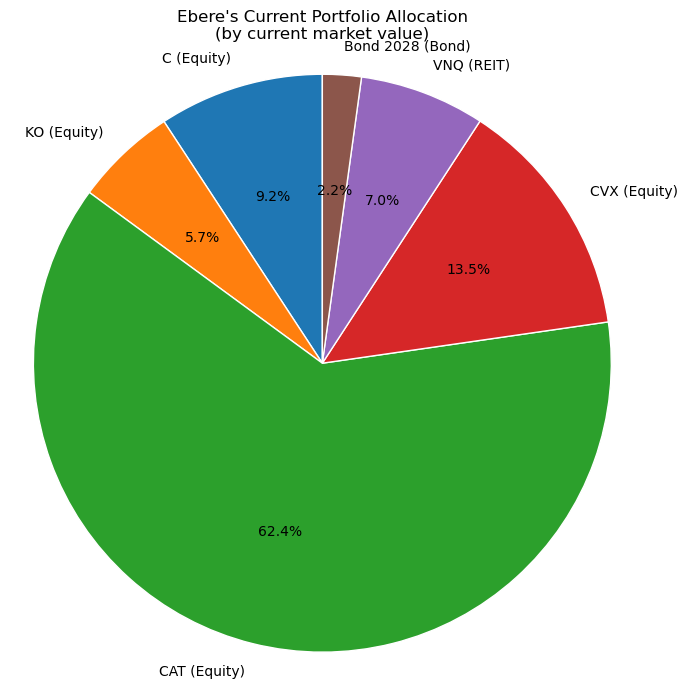


Allocation pie chart saved to: portfolio_allocation.png



Save this summary to a CSV file too? (yes/no):  no


In [8]:
# Main
def main():
    client_name = get_client_name()
    holdings = collect_holdings()

    if not holdings:
        print("\nNo investments were added. Exiting.")
        sys.exit(0)

    df, df_display = build_summary_table(holdings)
    print_table(df_display)

    chart_path = plot_allocation_pie(df, client_name)
    print(f"\nAllocation pie chart saved to: {chart_path}")

    save_csv = ask("\nSave this summary to a CSV file too? (yes/no): ", default="yes").lower()
    if save_csv.startswith("y"):
        csv_path = f"{client_name.replace(' ', '_')}_portfolio_summary.csv"
        df.to_csv(csv_path, index=False)
        print(f"Summary saved to: {csv_path}")

if __name__ == "__main__":
    main()